<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/Chapter_3_Statistical_Experiments_and_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Statistical Experiments and Significance Testing

Dalam dunia data science dan bisnis, pengambilan keputusan sering kali didasarkan pada eksperimen komparatif (seperti pengujian A/B). Bab ini membahas bagaimana merancang eksperimen yang valid, menghindari bias, serta menguji signifikansi statistik untuk memastikan perbedaan yang diamati bukan sekadar kebetulan acak.

---

## 1. A/B Testing
* **Definisi:** Eksperimen terkontrol dengan dua kelompok (biasanya kelompok kontrol $A$ yang menerima pengalaman standar/eksisting, dan kelompok perlakuan $B$ yang menerima fitur atau modifikasi baru).
* **Tujuan:** Membandingkan metrik kunci (seperti tingkat konversi, klik, atau pendapatan) untuk menentukan secara empiris mana varian yang memberikan performa lebih baik.
* **Treatment vs Control Group:**
  * **Control Group:** Kelompok yang tidak diberi intervensi baru atau tetap menggunakan versi lama sebagai baseline pembanding.
  * **Treatment Group:** Kelompok yang dikenai perlakuan atau perubahan tertentu untuk diukur dampaknya.

---

## 2. Hypothesis Testing (Pengujian Hipotesis)
Pengujian hipotesis digunakan untuk membuktikan apakah asumsi atau klaim awal didukung oleh data yang signifikan:
* **Null Hypothesis ($H_0$):** Hipotesis awal yang menyatakan bahwa tidak ada perbedaan efek atau tidak ada hubungan antara variabel (perbedaan yang ada murni karena kebetulan acak).
* **Alternative Hypothesis ($H_a$ / $H_1$):** Hipotesis tandingan yang menyatakan ada perbedaan nyata atau efek yang signifikan dari perlakuan.
* **Resampling / Permutation Test:** Metode non-parametrik untuk menguji signifikansi dengan menggabungkan data dari kedua kelompok, lalu mengacaknya kembali secara berulang (*resampling*) untuk melihat seberapa sering perbedaan ekstrem seperti pada data asli dapat terjadi secara kebetulan.

---

## 3. P-Value, Alpha, dan Kesalahan Statistik
* **P-Value (Probability Value):** Probabilitas untuk mendapatkan hasil yang sama ekstremnya (atau lebih ekstrem) dengan hasil observasi saat ini, dengan asumsi bahwa hipotesis nol ($H_0$) benar.
* **Alpha ($\alpha$) / Significance Level:** Batas ambang toleransi risiko (biasanya ditetapkan 0.05 atau 5%). Jika $p$-value $<\alpha$, maka kita menolak $H_0$.
* **Type I Error (False Positive):** Kesalahan menyimpulkan bahwa ada efek/perbedaan padahal sebenarnya tidak ada ($H_0$ benar tapi ditolak).
* **Type II Error (False Negative):** Kesalahan menyimpulkan bahwa tidak ada efek padahal sebenarnya ada ($H_0$ salah tapi diterima).
* **Statistical Power:** Probabilitas bahwa suatu tes akan mendeteksi efek yang benar-benar ada (kemampuan menghindari Type II Error).

--- Ringkasan Data A/B Testing ---
Group
Control      0.05
Treatment    0.08
Name: Outcome, dtype: float64

Selisih Konversi (Treatment - Control): 3.00%

--- Hasil Permutation Test ---
Observed Difference : 0.0300
P-Value             : 0.0010
Kesimpulan: Tolak H0 (Perbedaan signifikan secara statistik)

--- Hasil Chi-Square Test ---
Chi2 Statistic      : 6.9190
P-Value (Chi2)      : 0.0085



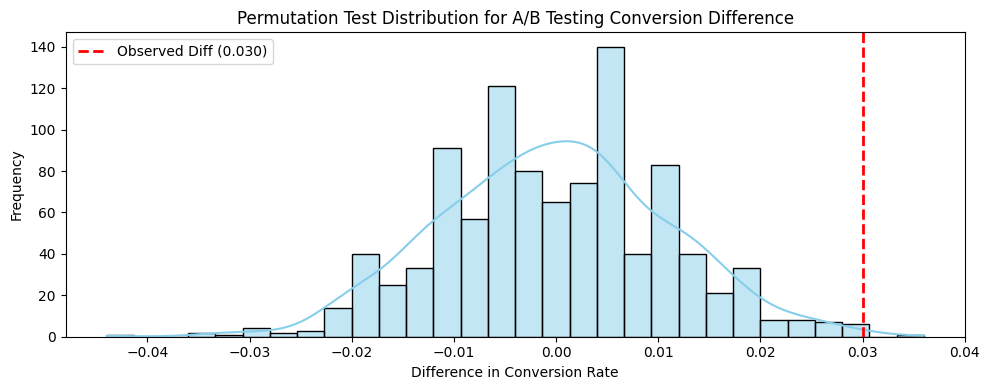

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# PERSIAPAN: Membuat Data Simulasi A/B Testing
# ==========================================
# Kita mensimulasikan tingkat konversi (0 = tidak konversi, 1 = konversi)
# antara dua kelompok: Kontrol dan Treatment
np.seed = 42
control = np.array([0]*950 + [1]*50)      # 50 konversi dari 1000 pengguna (5%)
treatment = np.array([0]*920 + [1]*80)    # 80 konversi dari 1000 pengguna (8%)

ab_data = pd.DataFrame({
    'Group': ['Control']*1000 + ['Treatment']*1000,
    'Outcome': np.concatenate([control, treatment])
})

print("--- Ringkasan Data A/B Testing ---")
conversion_rates = ab_data.groupby('Group')['Outcome'].mean()
print(conversion_rates)
print(f"\nSelisih Konversi (Treatment - Control): {(conversion_rates['Treatment'] - conversion_rates['Control']) * 100:.2f}%\n")


# ==========================================
# CONTOH PROGRAM 1: Permutation Test (Uji Permutasi)
# ==========================================
# Menguji apakah perbedaan konversi antara kedua kelompok benar-benar signifikan
# atau hanya terjadi karena kebetulan acak menggunakan teknik resampling permutasi.
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_b = set(np.random.choice(n, nB, replace=False))
    idx_a = set(range(n)) - idx_b
    return x.loc[list(idx_b)].mean() - x.loc[list(idx_a)].mean()

nA = len(control)
nB = len(treatment)
observed_diff = treatment.mean() - control.mean()

np.random.seed(42)
perm_diffs = [perm_fun(ab_data['Outcome'], nA, nB) for _ in range(1000)]
perm_diffs = pd.Series(perm_diffs)

# Menghitung p-value dari hasil permutasi
p_value = np.mean(perm_diffs > observed_diff)

print("--- Hasil Permutation Test ---")
print(f"Observed Difference : {observed_diff:.4f}")
print(f"P-Value             : {p_value:.4f}")
if p_value < 0.05:
    print("Kesimpulan: Tolak H0 (Perbedaan signifikan secara statistik)\n")
else:
    print("Kesimpulan: Gagal tolak H0 (Perbedaan tidak signifikan)\n")


# ==========================================
# CONTOH PROGRAM 2: Chi-Square Test for Independence
# ==========================================
# Menggunakan uji statistik Chi-Square standar untuk menguji data kategorikal A/B testing
contingency_table = pd.crosstab(ab_data['Group'], ab_data['Outcome'])
chi2, p_val_chi2, dof, ex = stats.chi2_contingency(contingency_table)

print("--- Hasil Chi-Square Test ---")
print(f"Chi2 Statistic      : {chi2:.4f}")
print(f"P-Value (Chi2)      : {p_val_chi2:.4f}\n")


# ==========================================
# CONTOH PROGRAM 3: Visualisasi Distribusi Permutation Test
# ==========================================
# Memvisualisasikan sebaran selisih acak hasil permutasi dibandingkan dengan
# selisih nyata (observed difference) yang didapat dari eksperimen.
plt.figure(figsize=(10, 4))
sns.histplot(perm_diffs, bins=30, color='skyblue', kde=True)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed Diff ({observed_diff:.3f})')
plt.title('Permutation Test Distribution for A/B Testing Conversion Difference')
plt.xlabel('Difference in Conversion Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()